Хiд виконання роботи
1. Завантажити початковi данi.
2. Представити данi графiчно.
3. Iнiцiалiзувати параметри: швидкiсть навчання, кiлькiсть епох (=100) i додатково, якщо задано згiдно з варiантом, кiлькiсть пакетiв i/або параметр регуляризацiї.
4. Iнiцiалiзувати вектор параметрiв.
5. Реалiзувати функцiю, яка задає модель, наприклад:
- лiнiйну регресiю,
- полiномiальну регресiю,
- iншу криву, яку пiдiбрати вiдповiдно до заданих даних.
6. Задати функцiю втрат (одну згiдно з варiантом):
- MSE,
- MSE з регуляризацiєю за нормами L1 або L2.
7. Задати операцiю, яка буде викликатися на кожнiй iтерацiї алгоритма навчання:
- алгоритм стохастичного градiєнтного спуску,
- алгоритм мiнi-пакетного градiєнтного спуску,
- алгоритм стохастичного градiєнтного спуску з моментом,
- алгоритм Adagrad,
- алгоритм Adadelta,
- алгоритм Adam.
8. Виконати навчання моделi.
9. Виводити значення функцiї втрат через кожнi 10 епох.
10. Зберегти контрольнi точки через регулярнi iнтервали пiд час навчання. В кiнцi навчання зберегти результуючу модель. Вiдновити останню контрольну точку при запуску, якщо навчання було перервано.
11. Налаштувати гiперпараметр швидкiсть навчання i додатково, якщо задано згiдно варiанту, розмiр мiнi-пакета. Подивитися на форму кривої навчання.
12. Дослiдити рiзнi значення параметра регуляризацiї i пiдiбрати найкраще з них, якщо згiдно з варiантом задано регуляризовану функцiю втрат. В цьому випадку данi мають бути попередньо розбитi на навчальний та перевiрочний набори.
13. Побудувати графiк з початковими даними та лiнiєю регресiї.

In [3]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split

# Варіант 3
Полiномiальна регресiя, алгоритм градiєнтного спуску з моментом, MSE з регуляризацiєю за нормою L1.

1. Завантажити початковi данi.

In [4]:
X_data = np.linspace(-1, 1, 100)
num_coef=5
coef = [10, 2, 30, 4, 5]
y_data=0
for i in range(num_coef):
    y_data += coef[i]*np.power(X_data, i)
    y_data += np.random.randn(*X_data.shape)*1.5

2. Представити данi графiчно.

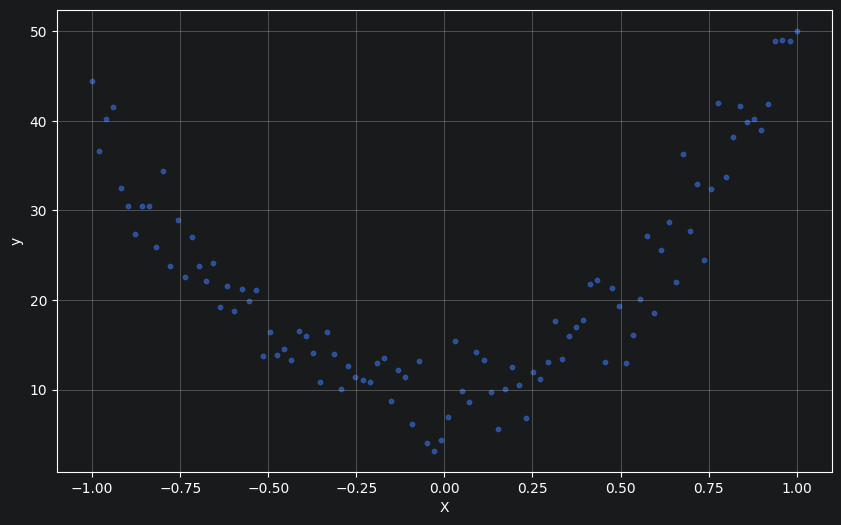

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(X_data, y_data, s=10, alpha=0.6)

plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

3. Iнiцiалiзувати параметри: швидкiсть навчання, кiлькiсть епох (=100) i додатково, якщо задано згiдно з варiантом, кiлькiсть пакетiв i/або параметр регуляризацiї.

In [6]:
learning_rate = 0.01
epochs = 100
l1_reg = 0.001

5. Реалiзувати функцiю, яка задає модель
6. Задати функцiю втрат
7. Задати операцiю, яка буде викликатися на кожнiй iтерацiї алгоритма навчання

In [7]:
def create_polynomial_regression_model(degree, l1_reg=0.01, learning_rate=0.01, momentum=0.9):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            units=1,
            input_shape=(degree,),
            use_bias=True,
            kernel_regularizer=tf.keras.regularizers.L1(l1_reg)
        )
    ])

    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)

    model.compile(optimizer=optimizer, loss='mse')
    return model

8. Виконати навчання моделi.
9. Виводити значення функцiї втрат через кожнi 10 епох.
10. Зберегти контрольнi точки через регулярнi iнтервали пiд час навчання. В кiнцi навчання зберегти результуючу модель. Вiдновити останню контрольну точку при запуску, якщо навчання було перервано.

In [8]:
class SaveEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, n_epochs, filepath):
        super().__init__()
        self.n_epochs = n_epochs
        self.filepath = filepath
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.n_epochs == 0:
            self.model.save(self.filepath)
            loss = logs.get('loss')
            val_loss = logs.get('val_loss')
            print(f"Епоха {epoch+1}: loss = {loss:.6f}, val_loss = {val_loss:.6f}")

degree = 4
checkpoint_path = "model_1_checkpoint.keras"

X_poly = np.column_stack([X_data**i for i in range(1, degree+1)])

if os.path.exists(checkpoint_path):
    print(f"Знайдено контрольну точку {checkpoint_path}. Завантажуємо модель.")
    model = tf.keras.models.load_model(checkpoint_path)
else:
    print("Контрольну точку не знайдено. Створюємо нову модель.")
    model = create_polynomial_regression_model(degree, l1_reg, learning_rate)

print_loss_cb = SaveEveryNEpochs(n_epochs=10, filepath=checkpoint_path)

history = model.fit(
    X_poly, y_data,
    epochs=epochs,
    batch_size=len(X_poly),
    validation_split=0.2,
    callbacks=print_loss_cb,
    verbose=0
)

final_model_path = "final_model_1.keras"
model.save(final_model_path)
print(f"\nФінальну модель збережено як {final_model_path}")

weights, bias = model.layers[0].get_weights()
print("Коефіцієнти для степенів 1 - 4:", weights.flatten())
print("Зсув:", bias[0])

Контрольну точку не знайдено. Створюємо нову модель.


D:\КПІ\Лаби і стафф\ІСППР\Лаб1\DM2Lab1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Епоха 10: loss = 61.082146, val_loss = 720.625000
Епоха 20: loss = 63.418327, val_loss = 385.352814
Епоха 30: loss = 28.258183, val_loss = 499.384766
Епоха 40: loss = 24.098166, val_loss = 585.560425
Епоха 50: loss = 19.561113, val_loss = 488.716644
Епоха 60: loss = 17.530787, val_loss = 394.357269
Епоха 70: loss = 16.178669, val_loss = 359.543488
Епоха 80: loss = 15.137385, val_loss = 335.788727
Епоха 90: loss = 14.388371, val_loss = 302.027100
Епоха 100: loss = 13.769850, val_loss = 270.925598

Фінальну модель збережено як final_model_1.keras
Коефіцієнти для степенів 1 - 4: [-0.5946719 13.849605  -5.4824924  8.134365 ]
Зсув: 12.106054


11. Налаштувати гiперпараметр швидкiсть навчання i додатково, якщо задано згiдно варiанту, розмiр мiнi-пакета. Подивитися на форму кривої навчання.


Навчання з learning_rate = 0.001

Навчання з learning_rate = 0.005

Навчання з learning_rate = 0.01

Навчання з learning_rate = 0.05

Навчання з learning_rate = 0.1


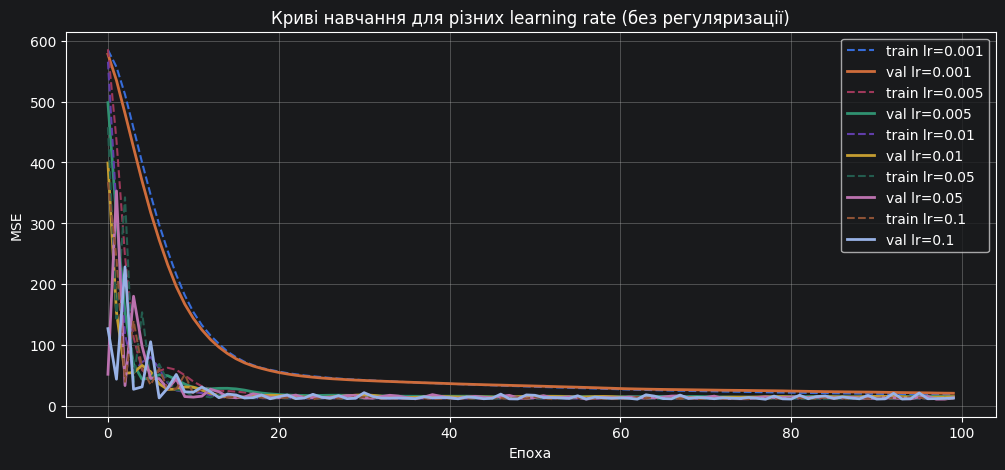


Найкращий learning rate: 0.1 (val_loss = 12.390666)


In [9]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
histories_lr = {}
plt.figure(figsize=(12, 5))

X_train, X_val, y_train, y_val = train_test_split(
    X_poly, y_data, test_size=0.2, random_state=42
)

for lr in learning_rates:
    print(f"\nНавчання з learning_rate = {lr}")
    model = create_polynomial_regression_model(degree=degree, l1_reg=0.0, learning_rate=lr, momentum=0.9)
    history = model.fit(
        X_poly, y_data,
        epochs=100,
        validation_data=(X_val, y_val),
        verbose=0
    )
    histories_lr[lr] = history
    plt.plot(history.history['loss'], label=f'train lr={lr}', linestyle='--')
    plt.plot(history.history['val_loss'], label=f'val lr={lr}', linewidth=2)

plt.xlabel('Епоха')
plt.ylabel('MSE')
plt.title('Криві навчання для різних learning rate (без регуляризації)')
plt.legend()
plt.grid(True)
plt.show()

best_lr = min(learning_rates, key=lambda lr: histories_lr[lr].history['val_loss'][-1])
print(f"\nНайкращий learning rate: {best_lr} (val_loss = {histories_lr[best_lr].history['val_loss'][-1]:.6f})")

12. Дослiдити рiзнi значення параметра регуляризацiї i пiдiбрати найкраще з них, якщо згiдно з варiантом задано регуляризовану функцiю втрат. В цьому випадку данi мають бути попередньо розбитi на навчальний та перевiрочний набори.


Навчання з L1 = 0

Навчання з L1 = 1e-06

Навчання з L1 = 1e-05

Навчання з L1 = 0.0001

Навчання з L1 = 0.001

Навчання з L1 = 0.01


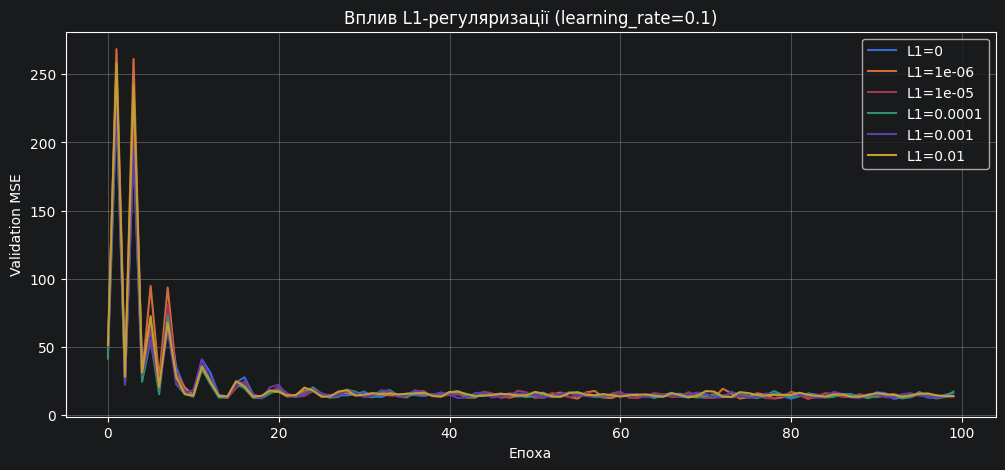

L1 =        0 : val_loss = 16.107344
L1 =    1e-06 : val_loss = 13.708948
L1 =    1e-05 : val_loss = 13.402681
L1 =   0.0001 : val_loss = 16.993990
L1 =    0.001 : val_loss = 13.411337
L1 =     0.01 : val_loss = 13.861559

Найкращий параметр L1: 1e-05 (val_loss = 13.402681)


In [10]:
l1_values = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
histories_l1 = {}

plt.figure(figsize=(12, 5))
for l1 in l1_values:
    print(f"\nНавчання з L1 = {l1}")
    model = create_polynomial_regression_model(degree=degree, l1_reg=l1, learning_rate=best_lr, momentum=0.9)
    history = model.fit(
        X_train, y_train,
        epochs=100,
        validation_data=(X_val, y_val),
        verbose=0
    )
    histories_l1[l1] = history
    plt.plot(history.history['val_loss'], label=f'L1={l1}')

plt.xlabel('Епоха')
plt.ylabel('Validation MSE')
plt.title(f'Вплив L1-регуляризації (learning_rate={best_lr})')
plt.legend()
plt.grid(True)
plt.show()

best_l1 = min(l1_values, key=lambda l1: histories_l1[l1].history['val_loss'][-1])
best_val_loss = histories_l1[best_l1].history['val_loss'][-1]

for l1 in l1_values:
    final_val_loss = histories_l1[l1].history['val_loss'][-1]
    print(f"L1 = {l1:8} : val_loss = {final_val_loss:.6f}")

print(f"\nНайкращий параметр L1: {best_l1} (val_loss = {best_val_loss:.6f})")

13. Побудувати графiк з початковими даними та лiнiєю регресiї.


Навчання фінальної моделі на всіх даних для візуалізації...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


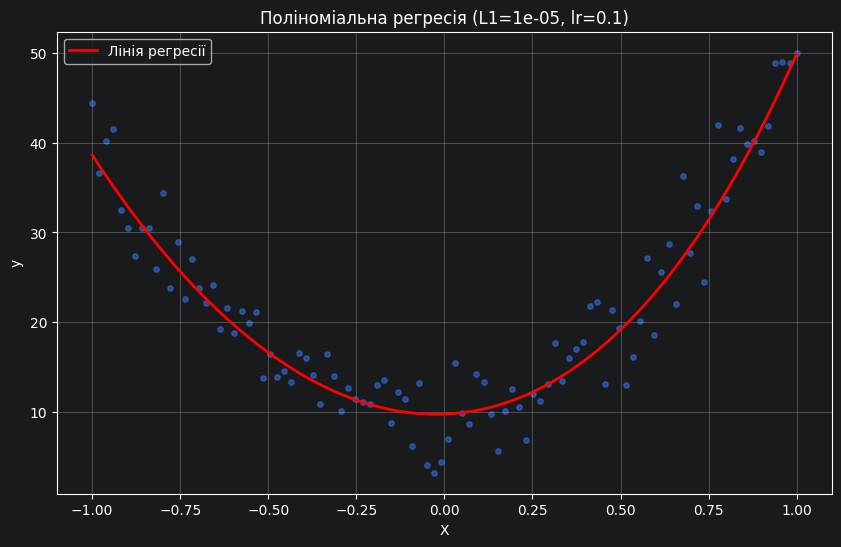

Коефіцієнти для степенів 1 - 4: [ 1.5134284 31.932142   4.121691   2.6416938]
Зсув: 9.722623


In [12]:
print("\nНавчання фінальної моделі на всіх даних для візуалізації...")
final_model = create_polynomial_regression_model(degree=degree, l1_reg=best_l1, learning_rate=best_lr, momentum=0.9)
final_model.fit(X_poly, y_data, epochs=100, verbose=0)

X_smooth = np.linspace(-1, 1, 200).reshape(-1, 1)
X_smooth_poly = np.column_stack([X_smooth**i for i in range(1, degree+1)])
y_pred_smooth = final_model.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X_data, y_data, s=15, alpha=0.6)
plt.plot(X_smooth, y_pred_smooth, 'r-', linewidth=2, label='Лінія регресії')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Поліноміальна регресія (L1={best_l1}, lr={best_lr})')
plt.legend()
plt.grid(True)
plt.show()
weights, bias = final_model.layers[0].get_weights()
print("Коефіцієнти для степенів 1 - 4:", weights.flatten())
print("Зсув:", bias[0])

Висновок: В ході роботи було навчено регресійну поліноміальну модель методами TensorFlow, проведено дослідження впливу гіперпараметрів на її ефективність та знайдено найефективнішу модель, коефіцієнти якої значно більше нагадують істинні.